In [1]:
# import librarys


import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
df = pd.read_csv("divar.csv")


C:\Users\Amin\AppData\Local\Temp\ipykernel_12344\3274903217.py:1: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("divar.csv")


In [4]:
df.describe()

,Unnamed: 0,rent_value,price_value,credit_value,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,regular_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
count,1000000.000000,3.513220e+05,5.683460e+05,3.520950e+05,3.520850e+05,7.240900e+04,3.512480e+05,7.240900e+04,1.863960e+05,9.803940e+05,29870.000000,1.024100e+04,1.806800e+04,1.046300e+04,1.355100e+04,655608.000000,655608.000000,339699.000000
mean,499999.500000,4.102299e+10,1.736537e+10,4.872084e+10,4.872222e+10,8.557025e+09,4.103164e+10,1.619934e+07,4.165480e+03,4.440648e+03,6.557650,1.209785e+10,1.389016e+11,2.355548e+10,3.156551e+10,34.982108,51.629743,465.149147
std,288675.278932,3.807534e+12,5.878739e+11,4.341346e+12,4.341407e+12,2.064576e+12,3.807935e+12,5.217890e+07,1.218927e+05,1.367118e+05,7.698655,1.103482e+12,7.042335e+12,1.542049e+12,2.434942e+12,2.379169,3.160920,125.896250
min,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,23.626478,40.162369,0.000000
25%,249999.750000,1.111110e+05,1.400000e+09,1.000000e+08,1.000000e+08,2.000000e+08,1.111110e+05,1.000000e+06,1.100000e+02,7.500000e+01,3.000000,5.000000e+04,4.000000e+05,6.000000e+05,5.500000e+05,34.553551,50.677175,500.000000
50%,499999.500000,5.000000e+06,2.840000e+09,2.500000e+08,2.500000e+08,4.000000e+08,5.000000e+06,6.000000e+06,1.950000e+02,1.030000e+02,4.000000,1.000000e+05,8.000000e+05,1.200000e+06,1.100000e+06,35.723312,51.345791,500.000000
75%,749999.250000,1.200000e+07,5.900000e+09,5.000000e+08,5.000000e+08,8.500000e+08,1.200000e+07,1.500000e+07,2.800000e+02,1.650000e+02,7.000000,2.000000e+05,1.600000e+06,2.500000e+06,2.500000e+06,36.307013,51.805291,500.000000
max,999999.000000,1.000000e+15,1.000000e+14,1.000000e+15,1.000000e+15,5.555556e+14,1.000000e+15,3.000000e+09,1.000000e+07,1.000000e+07,50.000000,1.111111e+14,5.006007e+14,1.111111e+14,2.002503e+14,40.358055,74.511620,500.000000


In [ ]:
print(df["price_value"].dtype)
    print(df["cat3_slug"].head(10))

print(df["cat3_slug"].isnull())
print(df["price_value"].isnull().sum())
print(df.groupby("cat3_slug")["price_value"].apply(lambda x: x.isnull().sum()))

float64
0             villa
1    apartment-sell
2    apartment-rent
3       office-rent
4    apartment-sell
5    apartment-rent
6       office-rent
7    apartment-sell
8    apartment-sell
9    apartment-sell
Name: cat3_slug, dtype: object
0         False
1         False
2         False
3         False
4         False
          ...  
999995    False
999996    False
999997    False
999998    False
999999    False
Name: cat3_slug, Length: 1000000, dtype: bool
431654
cat3_slug
apartment-rent                        211876
apartment-sell                             5
house-villa-rent                       64676
house-villa-sell                           5
industry-agriculture-business-rent      9150
industry-agriculture-business-sell      2763
office-rent                            21412
office-sell                              675
partnership                             3616
plot-old                               23734
presell                                14577
shop-rent                  

In [12]:
df["price_value"].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99, .999]
)

count    5.683460e+05
mean     1.736537e+10
std      5.878739e+11
min      0.000000e+00
1%       3.400000e+03
5%       2.600000e+08
25%      1.400000e+09
50%      2.840000e+09
75%      5.900000e+09
95%      2.100000e+10
99%      8.500000e+10
99.9%    1.111111e+12
max      1.000000e+14
Name: price_value, dtype: float64

In [15]:
df.nlargest(20, "price_value")[["cat3_slug", "price_value"]]

,cat3_slug,price_value
116854,apartment-sell,1.000000e+14
329748,plot-old,1.000000e+14
588194,house-villa-sell,1.000000e+14
740491,house-villa-sell,1.000000e+14
786984,house-villa-sell,1.000000e+14
927290,shop-sell,1.000000e+14
931774,plot-old,1.000000e+14
6406,apartment-sell,9.000000e+13
560251,apartment-sell,8.900000e+13
339009,apartment-sell,8.397000e+13


In [16]:
(df["price_value"] >= 1e13).sum()



np.int64(215)

In [ ]:
(df["price_value"] >= 1e12).sum()

np.int64(615)

In [ ]:
(df["price_value"] == 0).sum()

np.int64(1902)

In [19]:
df[df["price_value"] == 0]["cat3_slug"].value_counts()

cat3_slug
house-villa-sell                      965
apartment-sell                        738
shop-sell                             114
industry-agriculture-business-sell     59
office-sell                            25
presell                                 1
Name: count, dtype: int64

In [6]:
df_price = df[
    (df["price_value"] > 0) &
    (df["price_value"] < 1e12)
]

df_price.__len__()

565829

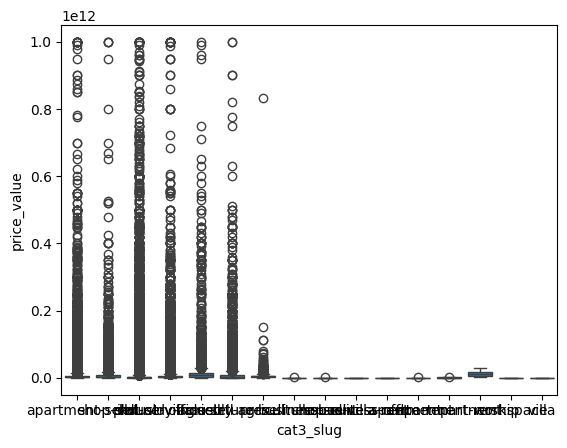

In [8]:
sns.boxplot(data=df_price, x="cat3_slug", y="price_value")
plt.show()